In [2]:
import numpy as np
from numpy.fft import fft2, ifft2, fftshift, ifftshift
import matplotlib.pyplot as plt

def padded_angular_spectrum(input_field, x_max_m, z_m, lambda_m, n_pad_pix):
    """
    Propagates an optical field using the Angular Spectrum method with padding.
    
    Parameters:
        input_field (ndarray): The input field (amplitude distribution).
        x_max_m (float): Maximum spatial extent (meters).
        z_m (float): Propagation distance (meters).
        lambda_m (float): Wavelength (meters).
        n_pad_pix (int): Number of pixels to pad.

    Returns:
        ndarray: Output field after propagation.
    """
    # Pad input field with zeros
    padded_input_field = np.pad(input_field, n_pad_pix, mode='constant')

    # Get sizes of padded and unpadded fields
    N_unpadded = input_field.shape[0]  # Assuming square input field
    N = padded_input_field.shape[0]  # Padded size

    # Compute spatial coordinates
    dx_m = 2 * x_max_m / (N_unpadded - 1)
    x_m = np.linspace(-(N - 1) * dx_m / 2, (N - 1) * dx_m / 2, N)

    # Compute frequency domain coordinates
    fx_max_pm = 1 / (2 * dx_m)  # Maximum frequency
    dfx_pm = 1 / (N * dx_m)  # Frequency step size

    if len(x_m) % 2 == 0:
        fx_pm = np.linspace(-fx_max_pm, fx_max_pm - dfx_pm, N)  # Even case
    else:
        fx_pm = np.linspace(-fx_max_pm, fx_max_pm, N)  # Odd case

    # Create frequency domain coordinate matrices
    kx_radpm = 2 * np.pi * fx_pm
    Kx_radpm, Ky_radpm = np.meshgrid(kx_radpm, kx_radpm)

    # Compute wavenumber
    k_radpm = 2 * np.pi / lambda_m

    # Compute transfer function (propagation kernel)
    kernel = np.exp(1j * z_m * np.sqrt(k_radpm**2 - Kx_radpm**2 - Ky_radpm**2))

    # Apply Angular Spectrum Method
    padded_input_fft = fftshift(fft2(padded_input_field))  # Forward FFT
    padded_output_fft = padded_input_fft * kernel  # Multiply by transfer function
    padded_output_field = ifft2(ifftshift(padded_output_fft))  # Inverse FFT

    # Crop out the original field size
    output_field = padded_output_field[n_pad_pix:n_pad_pix + N_unpadded,
                                       n_pad_pix:n_pad_pix + N_unpadded]

    return output_field

# Question 1

In [3]:
if __name__ == "__main__":
    # Parameters
    x_max = 0.01  # 10mm in meters (half-width, so total width is 20mm)
    z_m = 0.5     # 500mm in meters
    n_pixels = 2000  # 2000x2000 pixels
    lambda_m = 500e-9  # Example wavelength: 500nm in meters (you might need to adjust this)
    n_pad_pix = 0  # No padding for now

    # Create coordinate system using meshgrid
    x = np.linspace(-x_max, x_max, n_pixels)
    y = np.linspace(-x_max, x_max, n_pixels)
    X, Y = np.meshgrid(x, y)
    Z = np.full((n_pixels, n_pixels), z_m)  # 2D array with constant z value of 0.5m

    # Create initial field (example: point source at center)
    # For a point source, we'll create a delta-like function at the center
    input_field = np.zeros((n_pixels, n_pixels), dtype=complex)
    center_idx = n_pixels // 2
    input_field[center_idx, center_idx] = 1.0  # Point source at center

    # Call the propagation function
    output_field = padded_angular_spectrum(
        input_field=input_field,
        x_max_m=x_max,
        z_m=z_m,
        lambda_m=lambda_m,
        n_pad_pix=n_pad_pix
    )

    # The result is stored in output_field
    print(f"Input field shape: {input_field.shape}")
    print(f"Output field shape: {output_field.shape}")
    print(f"Coordinate arrays shape: {X.shape}, {Y.shape}, {Z.shape}")

Input field shape: (2000, 2000)
Output field shape: (2000, 2000)
Coordinate arrays shape: (2000, 2000), (2000, 2000), (2000, 2000)


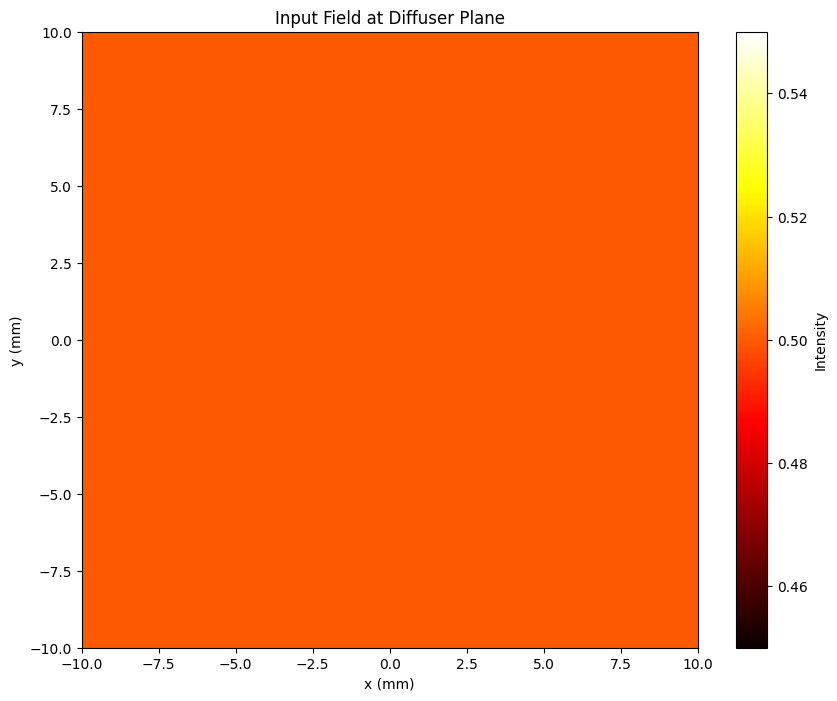

In [5]:
# Plot the input field
plt.figure(figsize=(10, 8))
plt.imshow(Z, 
            extent=[-x_max*1000, x_max*1000, -x_max*1000, x_max*1000],
            cmap='hot')
plt.colorbar(label='Intensity')
plt.xlabel('x (mm)')
plt.ylabel('y (mm)')
plt.title('Input Field at Diffuser Plane')
plt.show()

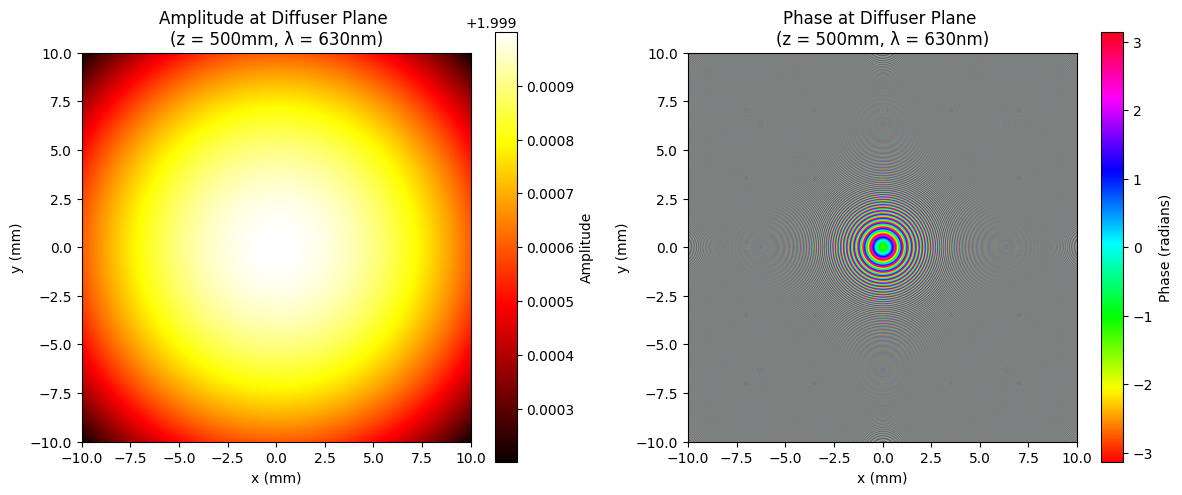

Input field shape: (2000, 2000)
Output field shape: (2000, 2000)
Maximum amplitude: 2.00e+00
Minimum amplitude: 2.00e+00
Maximum phase: 3.14 radians
Minimum phase: -3.14 radians


In [8]:
if __name__ == "__main__":
    # Parameters
    x_max = 0.01    # 10mm half-width in meters
    z_m = 0.5       # 500mm in meters
    n_pixels = 2000 # 2000x2000 pixels
    lambda_m = 630e-9  # 630nm wavelength in meters
    n_pad_pix = 0   # No padding

    # Create coordinate system at diffuser plane (z = 500mm)
    x = np.linspace(-x_max, x_max, n_pixels)
    y = np.linspace(-x_max, x_max, n_pixels)
    X, Y = np.meshgrid(x, y)
    Z = np.full((n_pixels, n_pixels), z_m)

    # Calculate distance from point source at (0,0,0) to each point on diffuser
    r = np.sqrt(X**2 + Y**2 + Z**2)
    
    # Calculate wave number
    k = 2 * np.pi / lambda_m
    
    # Create initial spherical wave field at diffuser plane
    # U(r) = A/r * exp(ikr), let's set A = 1 for simplicity
    A = 1.0
    input_field = (A / r) * np.exp(1j * k * r)

    # Propagate field (though in this case we're calculating directly at the plane)
    # We could skip propagation since we're calculating the field directly,
    # but let's use the propagator for consistency with the problem statement
    output_field = padded_angular_spectrum(
        input_field=input_field,
        x_max_m=x_max,
        z_m=0,  # No additional propagation needed since we calculated at z=500mm
        lambda_m=lambda_m,
        n_pad_pix=n_pad_pix
    )

# Calculate amplitude and phase
    amplitude = np.abs(output_field)
    phase = np.angle(output_field)

    # Plot amplitude and phase side by side
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    # Plot Amplitude
    im1 = axs[0].imshow(amplitude, 
                        extent=[-x_max*1000, x_max*1000, -x_max*1000, x_max*1000], 
                        cmap='hot')
    axs[0].set_title('Amplitude at Diffuser Plane \n(z = 500mm, λ = 630nm)')
    axs[0].set_xlabel('x (mm)')
    axs[0].set_ylabel('y (mm)')
    plt.colorbar(im1, ax=axs[0], label='Amplitude')

    # Plot Phase
    im2 = axs[1].imshow(phase, 
                        extent=[-x_max*1000, x_max*1000, -x_max*1000, x_max*1000], 
                        cmap='hsv')
    axs[1].set_title('Phase at Diffuser Plane \n(z = 500mm, λ = 630nm)')
    axs[1].set_xlabel('x (mm)')
    axs[1].set_ylabel('y (mm)')
    plt.colorbar(im2, ax=axs[1], label='Phase (radians)')

    # Adjust layout and display
    plt.tight_layout()
    plt.show()

    # Print some information
    print(f"Input field shape: {input_field.shape}")
    print(f"Output field shape: {output_field.shape}")
    print(f"Maximum amplitude: {np.max(amplitude):.2e}")
    print(f"Minimum amplitude: {np.min(amplitude):.2e}")
    print(f"Maximum phase: {np.max(phase):.2f} radians")
    print(f"Minimum phase: {np.min(phase):.2f} radians")

# Question 3 and 4

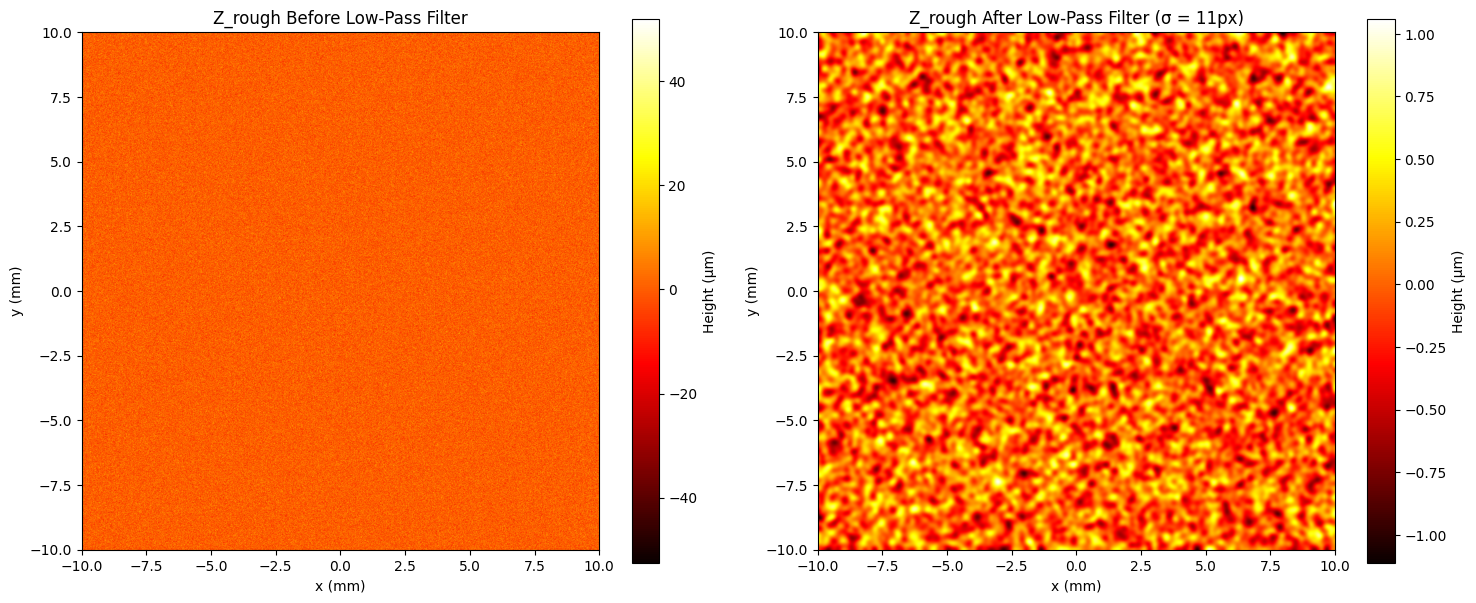

In [11]:
from scipy.ndimage import gaussian_filter

if __name__ == "__main__":
    # Parameters
    x_max = 0.01    # 10mm half-width in meters
    z_m = 0.5       # 500mm in meters
    n_pixels = 2000 # 2000x2000 pixels
    lambda_m = 630e-9  # 630nm wavelength in meters
    n_pad_pix = 0   # No padding
    sigma = 10e-6      # 10 μm roughness standard deviation in meters
    sigma_filter = 11    # Sigma for Gaussian filter in pixels

    # Add surface roughness
    zrough_raw = sigma * np.random.randn(n_pixels, n_pixels)  # Gaussian random height with σ = 10 μm
    zrough = gaussian_filter(zrough_raw, sigma=sigma_filter)

# Plot zrough_raw and zrough side by side
    plt.figure(figsize=(15, 6))
    
    # Left subplot: zrough_raw
    plt.subplot(1, 2, 1)
    plt.imshow(zrough_raw * 1e6,  # Convert to μm for better visibility
               cmap='hot',
               extent=[-x_max*1000, x_max*1000, -x_max*1000, x_max*1000])
    plt.colorbar(label='Height (μm)')
    plt.xlabel('x (mm)')
    plt.ylabel('y (mm)')
    plt.title('Z_rough Before Low-Pass Filter')

    # Right subplot: zrough
    plt.subplot(1, 2, 2)
    plt.imshow(zrough * 1e6,  # Convert to μm for better visibility
               cmap='hot',
               extent=[-x_max*1000, x_max*1000, -x_max*1000, x_max*1000])
    plt.colorbar(label='Height (μm)')
    plt.xlabel('x (mm)')
    plt.ylabel('y (mm)')
    plt.title('Z_rough After Low-Pass Filter (σ = 11px)')
    
    plt.tight_layout()
    plt.show()


## Question 5 

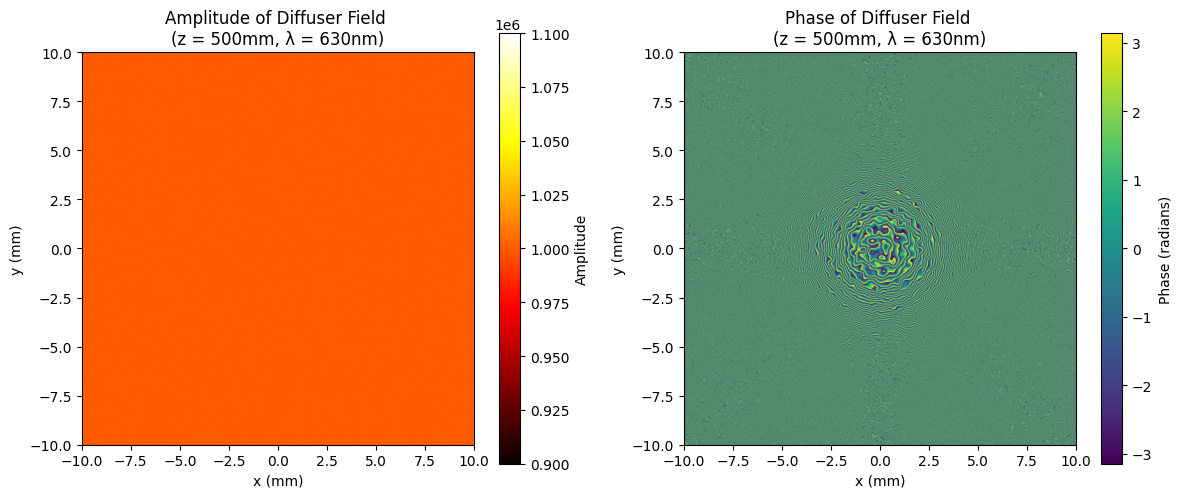

Field shape: (2000, 2000)
Maximum amplitude: 1.00e+00
Minimum amplitude: 1.00e+00
Maximum phase: 3.14 radians
Minimum phase: -3.14 radians


In [17]:
if __name__ == "__main__":
    # Parameters
    x_max = 0.01    # 10mm half-width in meters
    z_m = 0.5       # 500mm in meters
    n_pixels = 2000 # 2000x2000 pixels
    lambda_m = 630e-9  # 630nm wavelength in meters
    n_pad_pix = 0   # No padding
    sigma = 10e-6   # 10 μm roughness standard deviation in meters
    sigma_filter = 11    # Sigma for Gaussian filter in pixels
    n_refractive_index = 1 

    # Add surface roughness
    zrough_raw = sigma * np.random.randn(n_pixels, n_pixels)  # Gaussian random height with σ = 10 μm
    zrough = gaussian_filter(zrough_raw, sigma=sigma_filter)

    # Create coordinate system at diffuser plane (z = 500mm)
    x = np.linspace(-x_max, x_max, n_pixels)
    y = np.linspace(-x_max, x_max, n_pixels)
    X, Y = np.meshgrid(x, y)
    Z = np.full((n_pixels, n_pixels), z_m)

    # Phi rough 
    phi_rough = 2 * np.pi * zrough * n_refractive_index / lambda_m

    # Calculate distance from point source at (0,0,0) to each point on diffuser
    r = np.sqrt(X**2 + Y**2 + Z**2)
    # Calculate wave number
    k = 2 * np.pi / lambda_m
    
    theta_lambda = k * r
    # Create initial spherical wave field at diffuser plane (without amplitude factor)
    input_field_u = np.exp(1j * theta_lambda)
    # Add the roughness phase
    U_diffuser = np.exp(1j * (theta_lambda + phi_rough))
    

# Calculate amplitude and phase of U_diffuser
    amplitude = np.abs(U_diffuser)
    phase = np.angle(U_diffuser)

    # Plot amplitude and phase side by side
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    # Plot Amplitude
    im1 = axs[0].imshow(amplitude * 1e6,  # Convert to μm for better visibility, 
                        extent=[-x_max*1000, x_max*1000, -x_max*1000, x_max*1000], 
                        cmap='hot')
    axs[0].set_title('Amplitude of Diffuser Field \n(z = 500mm, λ = 630nm)')
    axs[0].set_xlabel('x (mm)')
    axs[0].set_ylabel('y (mm)')
    plt.colorbar(im1, ax=axs[0], label='Amplitude')

    # Plot Phase
    im2 = axs[1].imshow(phase, 
                        extent=[-x_max*1000, x_max*1000, -x_max*1000, x_max*1000], 
                        cmap='viridis')
    axs[1].set_title('Phase of Diffuser Field \n(z = 500mm, λ = 630nm)')
    axs[1].set_xlabel('x (mm)')
    axs[1].set_ylabel('y (mm)')
    plt.colorbar(im2, ax=axs[1], label='Phase (radians)')

    # Adjust layout and display
    plt.tight_layout()
    plt.show()

    # Print some information
    print(f"Field shape: {U_diffuser.shape}")
    print(f"Maximum amplitude: {np.max(amplitude):.2e}")
    print(f"Minimum amplitude: {np.min(amplitude):.2e}")
    print(f"Maximum phase: {np.max(phase):.2f} radians")
    print(f"Minimum phase: {np.min(phase):.2f} radians")

# Question 6

/var/folders/6q/b1f95jp528qg7gf5zww7z9h80000gn/T/ipykernel_71448/2119310624.py:125: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])
/var/folders/6q/b1f95jp528qg7gf5zww7z9h80000gn/T/ipykernel_71448/2119310624.py:127: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])


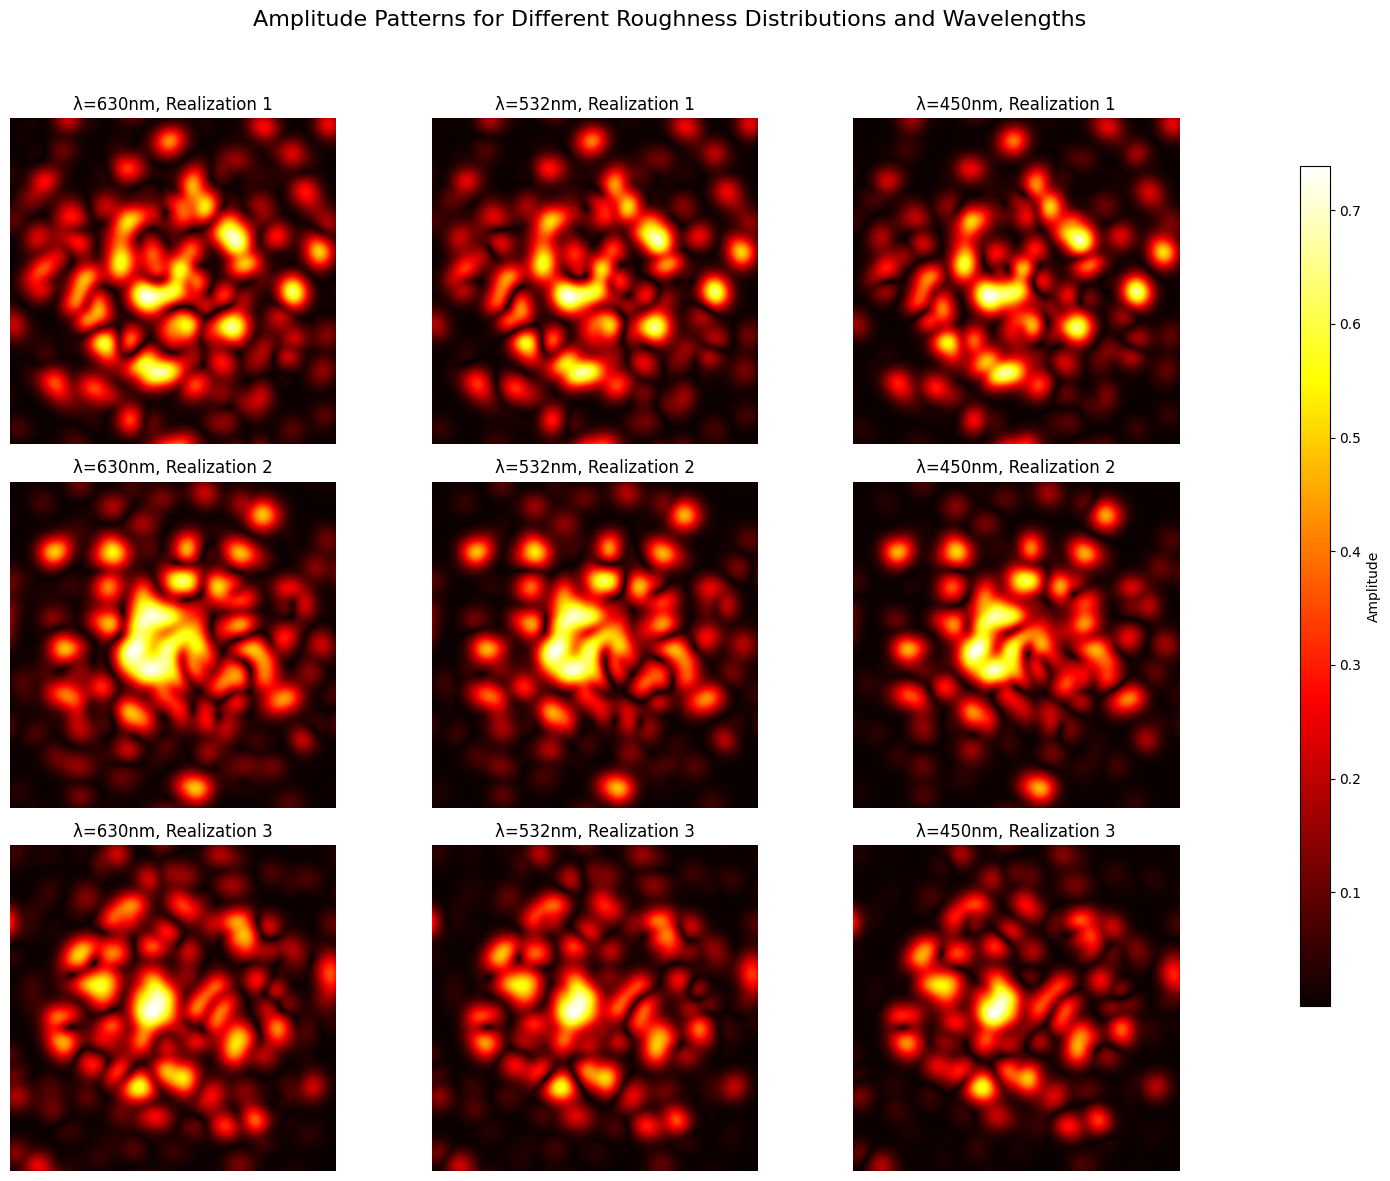

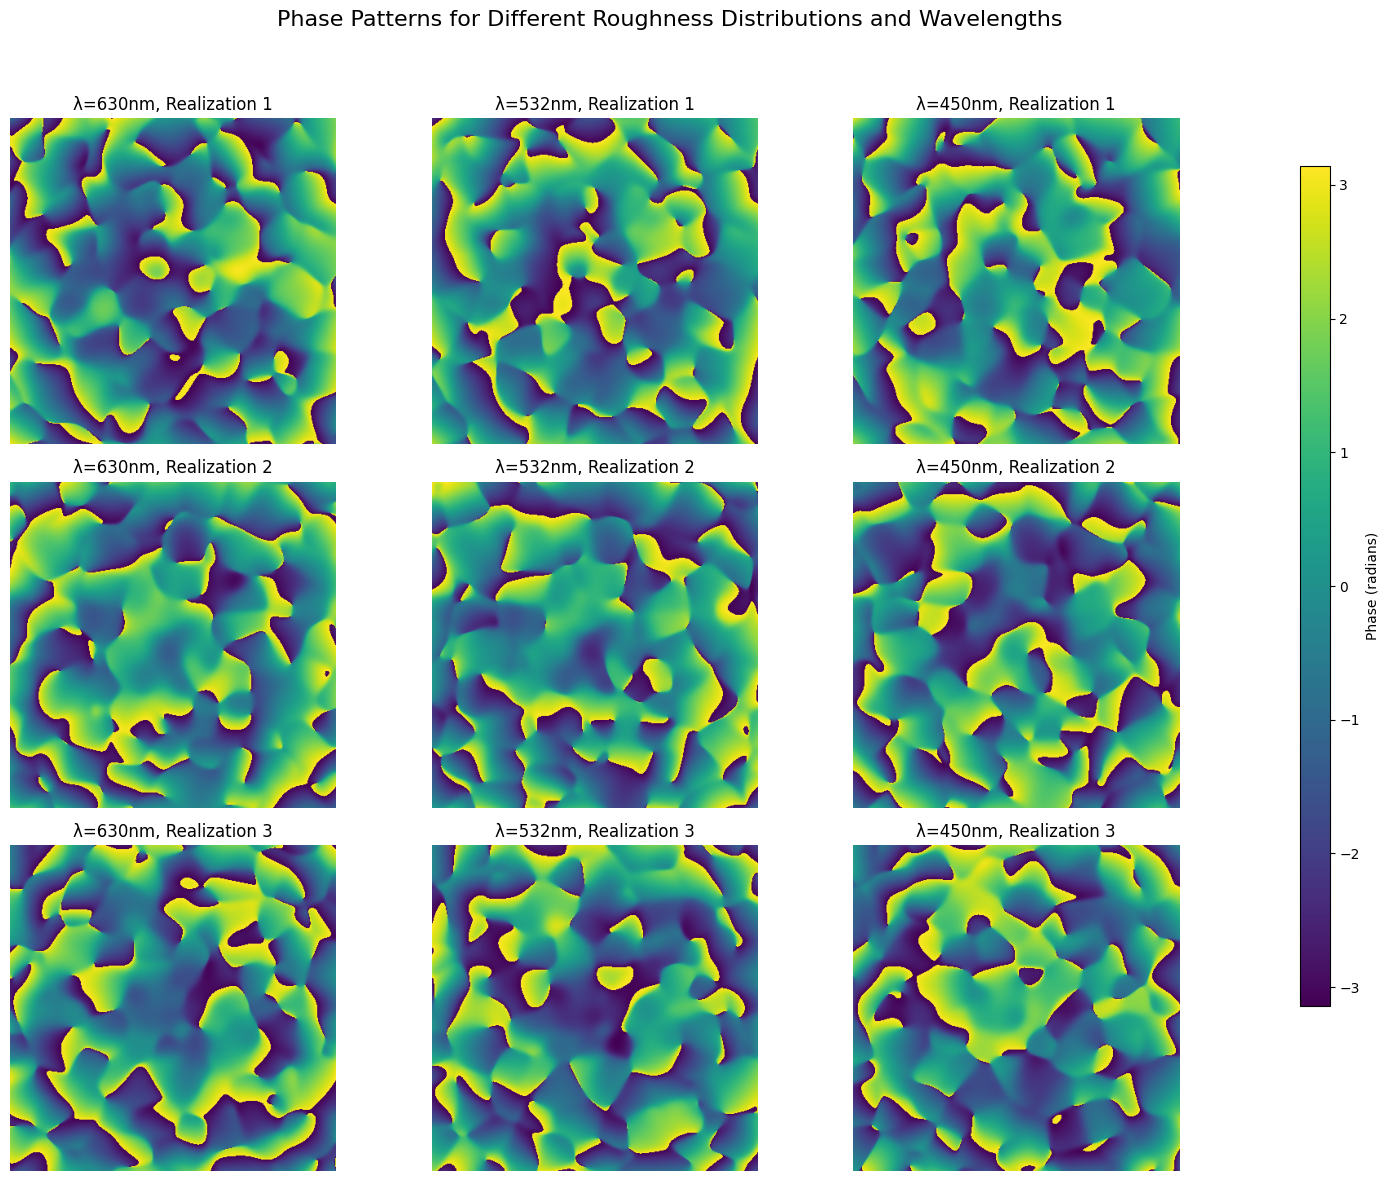

In [19]:
import numpy as np
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# Function to create a Gaussian kernel similar to MATLAB's fspecial('gaussian')
def fspecial_gaussian(shape=(3, 3), sigma=0.5):
    """
    Create a Gaussian kernel similar to MATLAB's fspecial('gaussian')
    
    Parameters:
    shape : tuple of int
        Size of the output kernel
    sigma : float
        Standard deviation of the Gaussian
        
    Returns:
    kernel : numpy.ndarray
        Normalized Gaussian kernel
    """
    m, n = [(ss-1.)/2. for ss in shape]
    y, x = np.ogrid[-m:m+1, -n:n+1]
    h = np.exp(-(x*x + y*y) / (2.*sigma*sigma))
    h[h < np.finfo(h.dtype).eps*h.max()] = 0
    sumh = h.sum()
    if sumh != 0:
        h /= sumh
    return h

if __name__ == "__main__":
    # Parameters
    x_max = 0.01      # 10mm half-width in meters
    z_m = 0.5         # 500mm in meters
    n_pixels = 2000   # 2000x2000 pixels
    n_pad_pix = 0     # No padding
    sigma = 10e-6     # 10 μm roughness standard deviation in meters
    sigma_filter = 11  # Sigma for Gaussian filter in pixels
    n_refractive_index = 1
    
    # Create additional wavelengths for comparison
    wavelengths = [630e-9, 532e-9, 450e-9]  # Red, Green, Blue wavelengths
    
    # Create multiple roughness distributions
    n_realizations = 3
    
    # Set up the figures for plotting (one for amplitude, one for phase)
    fig_amp, axs_amp = plt.subplots(n_realizations, len(wavelengths), figsize=(15, 12))
    fig_phase, axs_phase = plt.subplots(n_realizations, len(wavelengths), figsize=(15, 12))
    
    for i in range(n_realizations):
        # Add surface roughness - different realizations
        np.random.seed(i + 42)  # Set different seeds for reproducibility
        zrough_raw = sigma * np.random.randn(n_pixels, n_pixels)  # Gaussian random height with σ = 10 μm
        zrough = gaussian_filter(zrough_raw, sigma=sigma_filter)
        
        # Create coordinate system at diffuser plane (z = 500mm)
        x = np.linspace(-x_max, x_max, n_pixels)
        y = np.linspace(-x_max, x_max, n_pixels)
        X, Y = np.meshgrid(x, y)
        Z = np.full((n_pixels, n_pixels), z_m)
        
        # Calculate distance from point source at (0,0,0) to each point on diffuser
        r = np.sqrt(X**2 + Y**2 + Z**2)
        
        for j, lambda_m in enumerate(wavelengths):
            # Phi rough 
            phi_rough = 2 * np.pi * zrough * n_refractive_index / lambda_m
            
            # Calculate wave number
            k = 2 * np.pi / lambda_m
            
            theta_lambda = k * r
            # Create initial spherical wave field at diffuser plane (without amplitude factor)
            input_field_u = np.exp(1j * theta_lambda)
            # Add the roughness phase
            U_diffuser = np.exp(1j * (theta_lambda + phi_rough))
            
            # Low-pass filtering of the complex field using a Gaussian filter
            filter_size = 3  
            U_real_filtered = gaussian_filter(np.real(U_diffuser), sigma=sigma_filter)
            U_imag_filtered = gaussian_filter(np.imag(U_diffuser), sigma=sigma_filter)
            
            # Combine back to complex
            U_filtered = U_real_filtered + 1j * U_imag_filtered
            
            # Calculate amplitude and phase
            amplitude = np.abs(U_filtered)
            phase = np.angle(U_filtered)
            
            # Extract a smaller region for display (central 400x400 pixels)
            display_size = 400
            center = n_pixels // 2
            start_idx = center - display_size // 2
            end_idx = center + display_size // 2
            
            amplitude_display = amplitude[start_idx:end_idx, start_idx:end_idx]
            phase_display = phase[start_idx:end_idx, start_idx:end_idx]
            
            # Plot the amplitude
            wavelength_nm = int(lambda_m * 1e9)
            ax_amp = axs_amp[i, j]
            im_amp = ax_amp.imshow(amplitude_display, cmap='hot')
            ax_amp.set_title(f'λ={wavelength_nm}nm, Realization {i+1}')
            ax_amp.axis('off')
            
            # Plot the phase
            ax_phase = axs_phase[i, j]
            im_phase = ax_phase.imshow(phase_display, cmap='viridis')
            ax_phase.set_title(f'λ={wavelength_nm}nm, Realization {i+1}')
            ax_phase.axis('off')
    
    # Add colorbars
    cbar_ax_amp = fig_amp.add_axes([0.92, 0.15, 0.02, 0.7])
    fig_amp.colorbar(im_amp, cax=cbar_ax_amp, label='Amplitude')
    
    cbar_ax_phase = fig_phase.add_axes([0.92, 0.15, 0.02, 0.7])
    fig_phase.colorbar(im_phase, cax=cbar_ax_phase, label='Phase (radians)')
    
    # Add titles
    fig_amp.suptitle('Amplitude Patterns for Different Roughness Distributions and Wavelengths', fontsize=16)
    fig_phase.suptitle('Phase Patterns for Different Roughness Distributions and Wavelengths', fontsize=16)
    
    # Adjust layout
    plt.figure(fig_amp.number)
    plt.tight_layout(rect=[0, 0, 0.9, 0.95])
    plt.figure(fig_phase.number)
    plt.tight_layout(rect=[0, 0, 0.9, 0.95])
    
    # Show plots
    plt.show()

# Question 7

Correlation drops to 0.5 at wavelength: 2731.29 nm
Wavelength change needed for correlation to drop to 0.5: 2631.29 nm


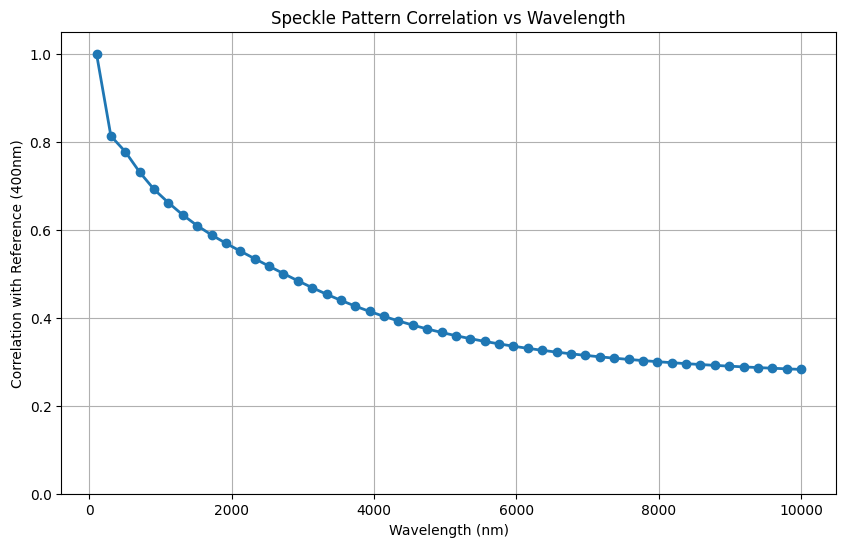

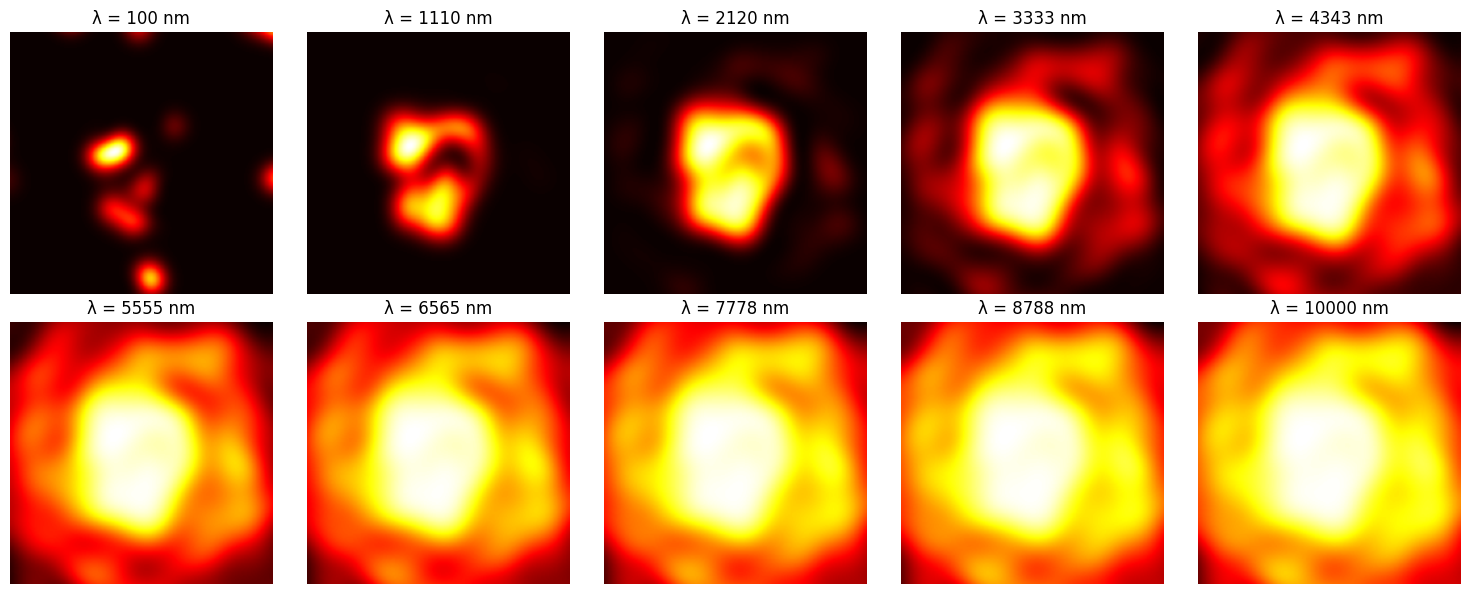

In [20]:
import numpy as np
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

def Corr2(A, B):
    """
    Calculate the correlation coefficient between two matrices A and B.
    This is equivalent to MATLAB's corr2() function.
    
    Parameters:
    A, B : numpy.ndarray
        Input matrices of the same size
        
    Returns:
    r : float
        Correlation coefficient between A and B
    """
    # Flatten the matrices
    A_flat = A.flatten()
    B_flat = B.flatten()
    
    # Calculate the correlation coefficient
    r, _ = pearsonr(A_flat, B_flat)
    return r

def main():
    # Parameters
    x_max = 0.01      # 10mm half-width in meters
    z_m = 0.5         # 500mm in meters
    n_pixels = 1000   # Using a smaller size for faster computation
    display_size = 200 # Size of the region to display
    
    # Parameters for the diffuser
    sigma = 10e-6     # 10 μm roughness standard deviation in meters
    sigma_filter = 11  # Sigma for Gaussian filter in pixels
    n_refractive_index = 1
    
    # Define wavelength range (wide enough to see significant changes)
    # Using 400nm to 800nm (visible spectrum)
    n_wavelengths = 50
    wavelengths = np.linspace(100e-9, 10000e-9, n_wavelengths)
    
    # Create a fixed diffuser (single realization)
    np.random.seed(42)  # For reproducibility
    zrough_raw = sigma * np.random.randn(n_pixels, n_pixels)
    zrough = gaussian_filter(zrough_raw, sigma=sigma_filter)
    
    # Create coordinate system at diffuser plane (z = 500mm)
    x = np.linspace(-x_max, x_max, n_pixels)
    y = np.linspace(-x_max, x_max, n_pixels)
    X, Y = np.meshgrid(x, y)
    Z = np.full((n_pixels, n_pixels), z_m)
    
    # Calculate distance from point source at (0,0,0) to each point on diffuser
    r = np.sqrt(X**2 + Y**2 + Z**2)
    
    # Storage for intensity patterns and correlations
    intensities = []
    correlations = []
    
    # Calculate intensity patterns for each wavelength
    for i, lambda_m in enumerate(wavelengths):
        # Phi rough (phase due to surface roughness)
        phi_rough = 2 * np.pi * zrough * n_refractive_index / lambda_m
        
        # Calculate wave number
        k = 2 * np.pi / lambda_m
        
        # Phase due to propagation
        theta_lambda = k * r
        
        # Create field at diffuser plane with roughness
        U_diffuser = np.exp(1j * (theta_lambda + phi_rough))
        
        # Low-pass filtering of the complex field
        U_real_filtered = gaussian_filter(np.real(U_diffuser), sigma=sigma_filter)
        U_imag_filtered = gaussian_filter(np.imag(U_diffuser), sigma=sigma_filter)
        U_filtered = U_real_filtered + 1j * U_imag_filtered
        
        # Calculate intensity
        intensity = np.abs(U_filtered)**2
        
        # Extract a region for display and analysis
        center = n_pixels // 2
        start_idx = center - display_size // 2
        end_idx = center + display_size // 2
        intensity_display = intensity[start_idx:end_idx, start_idx:end_idx]
        
        intensities.append(intensity_display)
    
    # Calculate correlation between first wavelength and all others
    reference_intensity = intensities[0]
    for intensity in intensities:
        correlation = Corr2(reference_intensity, intensity)
        correlations.append(correlation)
    
    # Convert wavelengths to nanometers for plotting
    wavelengths_nm = wavelengths * 1e9
    
    # Plot correlation vs wavelength
    plt.figure(figsize=(10, 6))
    plt.plot(wavelengths_nm, correlations, 'o-', linewidth=2)
    plt.xlabel('Wavelength (nm)')
    plt.ylabel('Correlation with Reference (400nm)')
    plt.title('Speckle Pattern Correlation vs Wavelength')
    plt.grid(True)
    plt.ylim(0, 1.05)
    plt.savefig('wavelength_correlation.png', dpi=300)
    
    # Plot a subset of the intensity patterns
    fig, axs = plt.subplots(2, 5, figsize=(15, 6))
    axs = axs.flatten()
    
    # Select 10 wavelengths to display
    indices = np.linspace(0, n_wavelengths-1, 10, dtype=int)
    
    for i, idx in enumerate(indices):
        axs[i].imshow(intensities[idx], cmap='hot')
        axs[i].set_title(f'λ = {wavelengths_nm[idx]:.0f} nm')
        axs[i].axis('off')
    
    plt.tight_layout()
    # plt.savefig('intensity_patterns.png', dpi=300)
    
    # Calculate and print the wavelength change needed for correlation to drop to 0.5
    # Find the wavelength where correlation first drops below 0.5
    for i in range(1, len(correlations)):
        if correlations[i] < 0.5:
            # Interpolate to find more precise wavelength
            lambda1 = wavelengths_nm[i-1]
            lambda2 = wavelengths_nm[i]
            corr1 = correlations[i-1]
            corr2 = correlations[i]
            
            # Linear interpolation
            lambda_half_corr = lambda1 + (lambda2 - lambda1) * (0.5 - corr1) / (corr2 - corr1)
            delta_lambda = lambda_half_corr - wavelengths_nm[0]
            
            print(f"Correlation drops to 0.5 at wavelength: {lambda_half_corr:.2f} nm")
            print(f"Wavelength change needed for correlation to drop to 0.5: {delta_lambda:.2f} nm")
            break
    
    plt.show()

if __name__ == "__main__":
    main()

# Question 8

For σ = 10 μm:
  Smallest correlation: 0.9181 at λ = 800 nm
  Highest correlation: 1.0000 at λ = 400 nm
For σ = 100 μm:
  Smallest correlation: 0.1730 at λ = 674 nm
  Highest correlation: 1.0000 at λ = 400 nm
For σ = 10 μm: Correlation did not drop below 0.5 in the given range
For σ = 100 μm:
  Correlation drops to 0.5 at wavelength: 425.25 nm
  Wavelength change needed: 25.25 nm


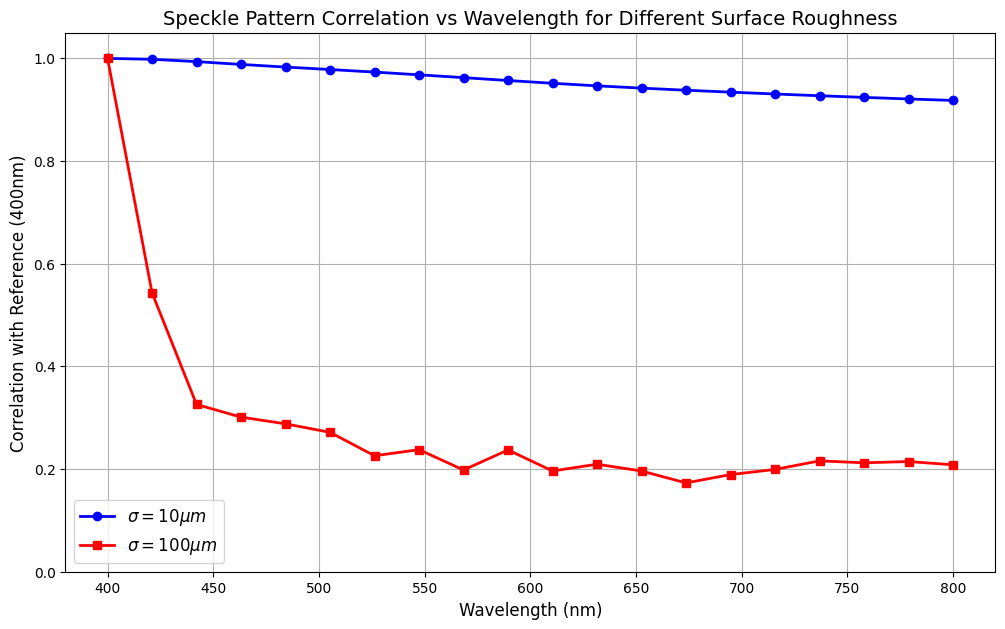

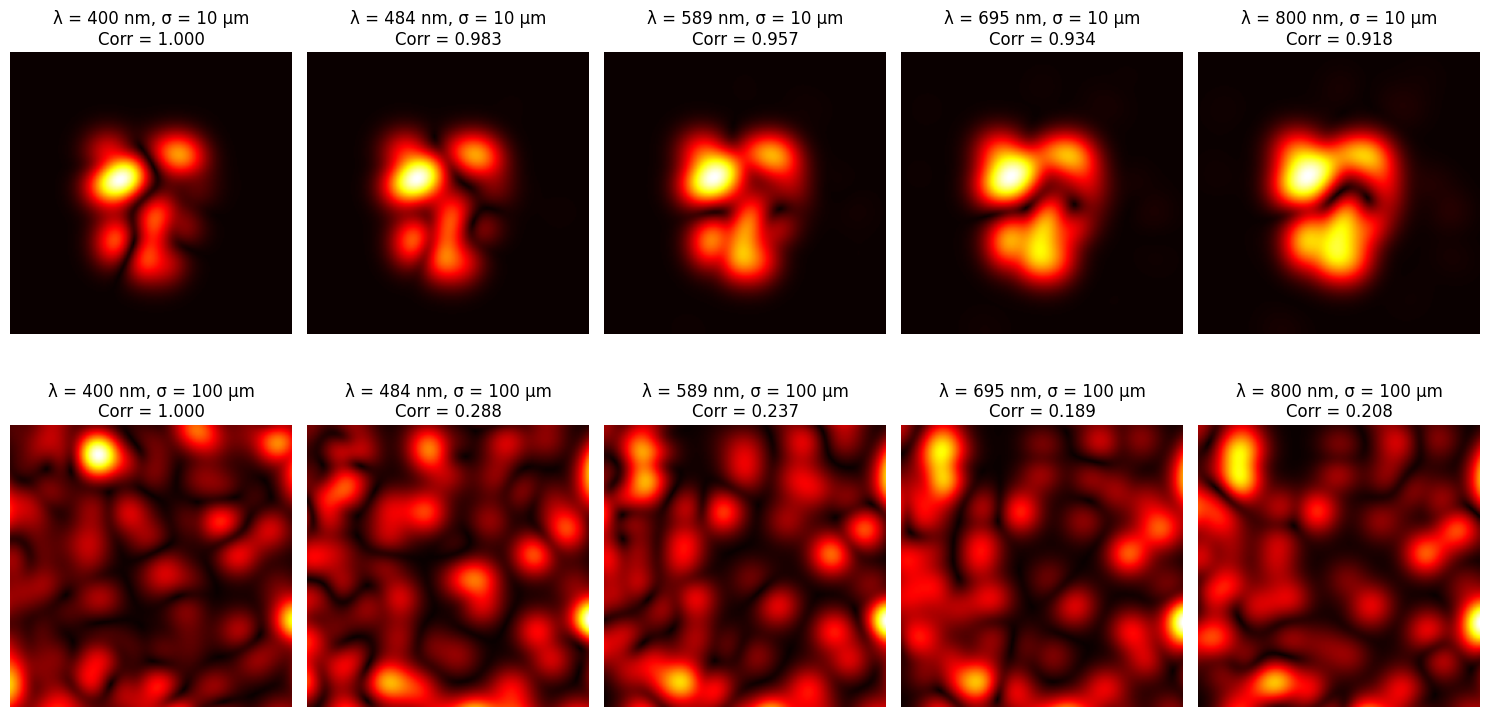

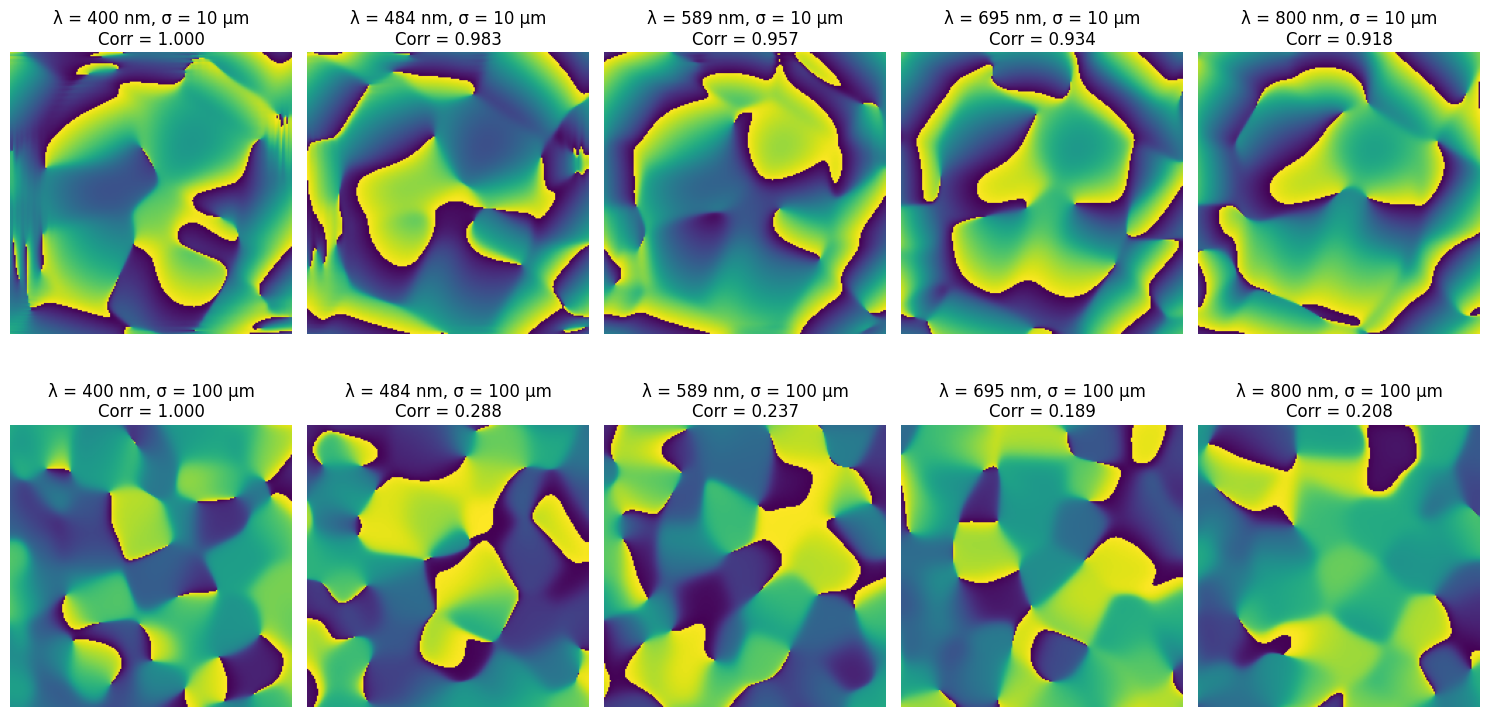

In [24]:
import numpy as np
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

def corr2(A, B):
    """
    Calculate the correlation coefficient between two matrices A and B.
    This is equivalent to MATLAB's corr2() function.
    
    Parameters:
    A, B : numpy.ndarray
        Input matrices of the same size
        
    Returns:
    r : float
        Correlation coefficient between A and B
    """
    A_flat = A.flatten()
    B_flat = B.flatten()
    r, _ = pearsonr(A_flat, B_flat)
    return r

def simulate_wavelength_correlation(sigma_roughness):
    """
    Simulate speckle patterns for different wavelengths with a given roughness value
    and return their correlation with the first pattern.
    
    Parameters:
    sigma_roughness : float
        Standard deviation of the surface roughness in meters
        
    Returns:
    wavelengths_nm : numpy.ndarray
        Wavelengths in nanometers
    correlations : list
        Correlation values for each wavelength
    amplitudes : list
        List of amplitude patterns
    phases : list
        List of phase patterns
    """
    # Parameters
    x_max = 0.01      # 10mm half-width in meters
    z_m = 0.5         # 500mm in meters
    n_pixels = 1000   # Using a smaller size for faster computation
    display_size = 200 # Size of the region to display
    
    # Parameters for the diffuser
    sigma_filter = 11  # Sigma for Gaussian filter in pixels
    n_refractive_index = 1
    
    # Define wavelength range (400nm to 800nm)
    n_wavelengths = 20
    wavelengths = np.linspace(400e-9, 800e-9, n_wavelengths)
    wavelengths_nm = wavelengths * 1e9
    
    # Create a fixed diffuser (single realization)
    np.random.seed(42)  # For reproducibility
    zrough_raw = sigma_roughness * np.random.randn(n_pixels, n_pixels)
    zrough = gaussian_filter(zrough_raw, sigma=sigma_filter)
    
    # Create coordinate system at diffuser plane (z = 500mm)
    x = np.linspace(-x_max, x_max, n_pixels)
    y = np.linspace(-x_max, x_max, n_pixels)
    X, Y = np.meshgrid(x, y)
    Z = np.full((n_pixels, n_pixels), z_m)
    
    # Calculate distance from point source at (0,0,0) to each point on diffuser
    r = np.sqrt(X**2 + Y**2 + Z**2)
    
    # Storage for amplitude, phase, and correlations
    amplitudes = []
    phases = []
    correlations = []
    
    # Calculate patterns for each wavelength
    for i, lambda_m in enumerate(wavelengths):
        # Phi rough (phase due to surface roughness)
        phi_rough = 2 * np.pi * zrough * n_refractive_index / lambda_m
        
        # Calculate wave number
        k = 2 * np.pi / lambda_m
        
        # Phase due to propagation
        theta_lambda = k * r
        
        # Create field at diffuser plane with roughness
        U_diffuser = np.exp(1j * (theta_lambda + phi_rough))
        
        # Low-pass filtering of the complex field
        U_real_filtered = gaussian_filter(np.real(U_diffuser), sigma=sigma_filter)
        U_imag_filtered = gaussian_filter(np.imag(U_diffuser), sigma=sigma_filter)
        U_filtered = U_real_filtered + 1j * U_imag_filtered
        
        # Calculate amplitude and phase
        amplitude = np.abs(U_filtered)
        phase = np.angle(U_filtered)
        
        # Extract a region for display and analysis
        center = n_pixels // 2
        start_idx = center - display_size // 2
        end_idx = center + display_size // 2
        amplitude_display = amplitude[start_idx:end_idx, start_idx:end_idx]
        phase_display = phase[start_idx:end_idx, start_idx:end_idx]
        
        amplitudes.append(amplitude_display)
        phases.append(phase_display)
    
    # Calculate correlation between first wavelength and all others (using amplitude)
    reference_amplitude = amplitudes[0]
    for amplitude in amplitudes:
        correlation = corr2(reference_amplitude, amplitude)
        correlations.append(correlation)
        
    return wavelengths_nm, correlations, amplitudes, phases

def main():
    # Simulate with two different roughness values
    sigma_1 = 10e-6   # 10 μm roughness
    sigma_2 = 100e-6  # 100 μm roughness
    
    # Run simulations
    wavelengths_nm, correlations_1, amplitudes_1, phases_1 = simulate_wavelength_correlation(sigma_1)
    _, correlations_2, amplitudes_2, phases_2 = simulate_wavelength_correlation(sigma_2)
    
    # Print smallest and highest correlations for each roughness
    print("For σ = 10 μm:")
    print(f"  Smallest correlation: {min(correlations_1):.4f} at λ = {wavelengths_nm[np.argmin(correlations_1)]:.0f} nm")
    print(f"  Highest correlation: {max(correlations_1):.4f} at λ = {wavelengths_nm[np.argmax(correlations_1)]:.0f} nm")
    print("For σ = 100 μm:")
    print(f"  Smallest correlation: {min(correlations_2):.4f} at λ = {wavelengths_nm[np.argmin(correlations_2)]:.0f} nm")
    print(f"  Highest correlation: {max(correlations_2):.4f} at λ = {wavelengths_nm[np.argmax(correlations_2)]:.0f} nm")
    
    # Plot correlation vs wavelength for both roughness values
    plt.figure(figsize=(12, 7))
    plt.plot(wavelengths_nm, correlations_1, 'o-', color='blue', linewidth=2, label=r'$\sigma = 10 \mu m$')
    plt.plot(wavelengths_nm, correlations_2, 's-', color='red', linewidth=2, label=r'$\sigma = 100 \mu m$')
    plt.xlabel('Wavelength (nm)', fontsize=12)
    plt.ylabel('Correlation with Reference (400nm)', fontsize=12)
    plt.title('Speckle Pattern Correlation vs Wavelength for Different Surface Roughness', fontsize=14)
    plt.grid(True)
    plt.ylim(0, 1.05)
    plt.legend(fontsize=12)
    plt.savefig('roughness_comparison.png', dpi=300)
    
    # Find wavelength for correlation = 0.5 for both cases
    for i, (correlations, sigma) in enumerate([(correlations_1, sigma_1), (correlations_2, sigma_2)]):
        sigma_um = sigma * 1e6  # Convert to μm for display
        found = False
        
        for j in range(1, len(correlations)):
            if correlations[j] < 0.5:
                # Interpolate to find more precise wavelength
                lambda1 = wavelengths_nm[j-1]
                lambda2 = wavelengths_nm[j]
                corr1 = correlations[j-1]
                corr2 = correlations[j]
                
                # Linear interpolation
                lambda_half_corr = lambda1 + (lambda2 - lambda1) * (0.5 - corr1) / (corr2 - corr1)
                delta_lambda = lambda_half_corr - wavelengths_nm[0]
                
                print(f"For σ = {sigma_um:.0f} μm:")
                print(f"  Correlation drops to 0.5 at wavelength: {lambda_half_corr:.2f} nm")
                print(f"  Wavelength change needed: {delta_lambda:.2f} nm")
                found = True
                break
        
        if not found:
            print(f"For σ = {sigma_um:.0f} μm: Correlation did not drop below 0.5 in the given range")
    
    # Plot amplitude patterns for both roughness values
    fig_amp, axs_amp = plt.subplots(2, 5, figsize=(15, 8))
    indices = [0, 4, 9, 14, 19]  # Indices for displaying a range of wavelengths
    
    # Plot for sigma_1 (amplitude)
    for i, idx in enumerate(indices):
        axs_amp[0, i].imshow(amplitudes_1[idx], cmap='hot')
        corr = correlations_1[idx]
        axs_amp[0, i].set_title(f'λ = {wavelengths_nm[idx]:.0f} nm, σ = 10 μm\nCorr = {corr:.3f}')
        axs_amp[0, i].axis('off')
    
    # Plot for sigma_2 (amplitude)
    for i, idx in enumerate(indices):
        axs_amp[1, i].imshow(amplitudes_2[idx], cmap='hot')
        corr = correlations_2[idx]
        axs_amp[1, i].set_title(f'λ = {wavelengths_nm[idx]:.0f} nm, σ = 100 μm\nCorr = {corr:.3f}')
        axs_amp[1, i].axis('off')
    
    plt.figure(fig_amp.number)
    plt.tight_layout()
    plt.savefig('amplitude_comparison.png', dpi=300)
    
    # Plot phase patterns for both roughness values
    fig_phase, axs_phase = plt.subplots(2, 5, figsize=(15, 8))
    
    # Plot for sigma_1 (phase)
    for i, idx in enumerate(indices):
        axs_phase[0, i].imshow(phases_1[idx], cmap='viridis')
        corr = correlations_1[idx]
        axs_phase[0, i].set_title(f'λ = {wavelengths_nm[idx]:.0f} nm, σ = 10 μm\nCorr = {corr:.3f}')
        axs_phase[0, i].axis('off')
    
    # Plot for sigma_2 (phase)
    for i, idx in enumerate(indices):
        axs_phase[1, i].imshow(phases_2[idx], cmap='viridis')
        corr = correlations_2[idx]
        axs_phase[1, i].set_title(f'λ = {wavelengths_nm[idx]:.0f} nm, σ = 100 μm\nCorr = {corr:.3f}')
        axs_phase[1, i].axis('off')
    
    plt.figure(fig_phase.number)
    plt.tight_layout()
    plt.savefig('phase_comparison.png', dpi=300)
    
    plt.show()

if __name__ == "__main__":
    main()

# Question 9

This occurs when I use the closest wavelength pairs in my simulation. With 20 equally spaced wavelengths from 400nm to 800nm, each consecutive pair is separated by (800-400)/19 = 21.05nm.
Taking the first two wavelengths:

λ₁ = 400nm
λ₂ = 421.05nm

Λₘₐₓ = (400 × 421.05) / |400 - 421.05|
= 168,420 / 21.05
≈ 8,000nm = 8μm
Minimum Synthetic Wavelength:
This occurs when I use the most distant wavelength pairs, which would be:

λ₁ = 400nm
λ₂ = 800nm

Λₘᵢₙ = (400 × 800) / |400 - 800|
= 320,000 / 400
= 800nm
Therefore, with my chosen wavelength range of 400-800nm:

Maximum synthetic wavelength: approximately 8μm
Minimum synthetic wavelength: 800nm

# Question 10

λ1 = 630.00 nm
λ2 = 630.66 nm
Synthetic wavelength Λ = 600.00 μm
Wavelength difference Δλ = 0.6622 nm


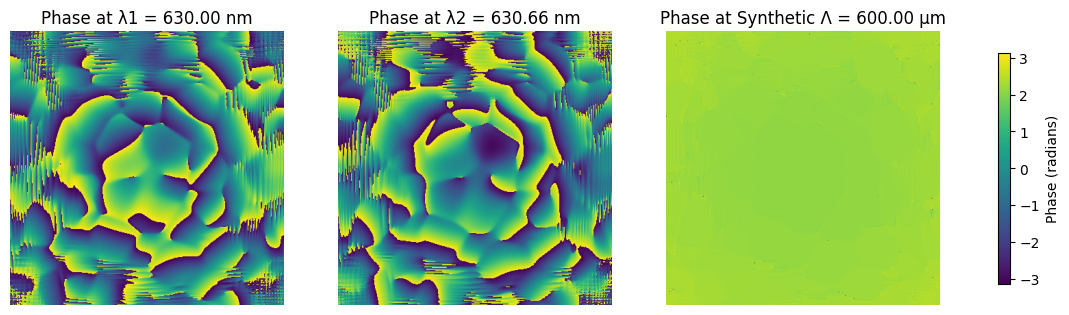

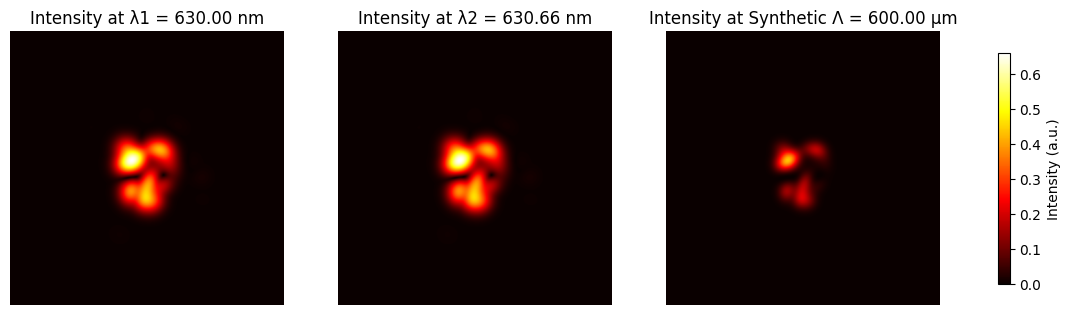

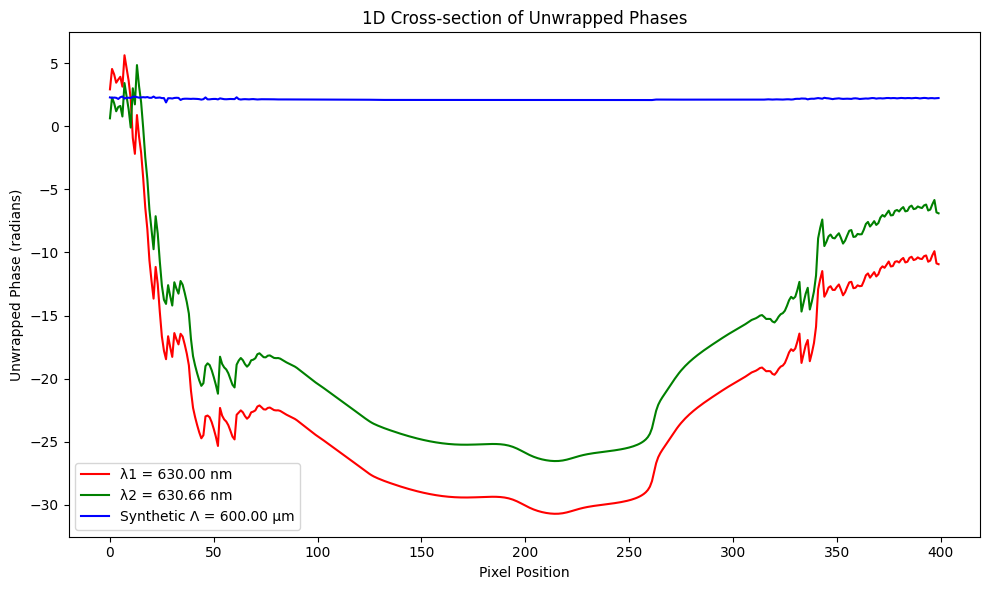

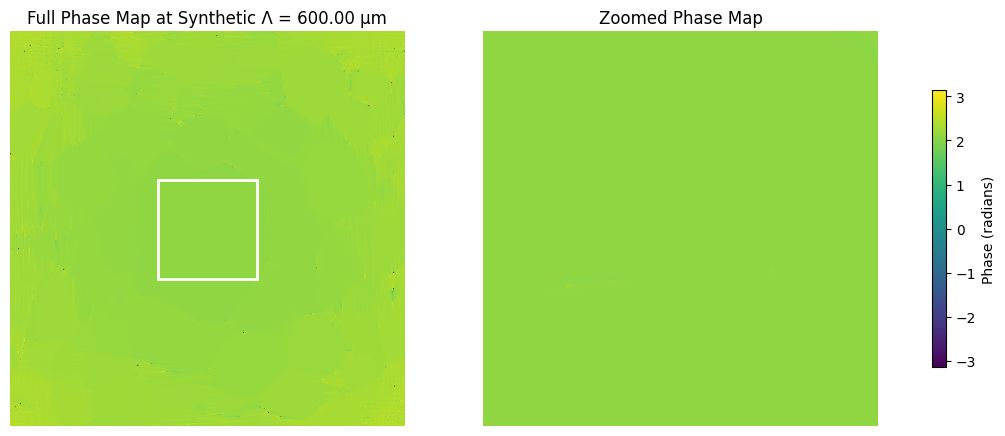

In [28]:
import numpy as np
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

def main():
    # Parameters
    x_max = 0.01      # 10mm half-width in meters
    z_m = 0.5         # 500mm in meters
    n_pixels = 1000   # Using a smaller size for faster computation
    display_size = 400 # Size of the region to display
    
    # Parameters for the diffuser
    sigma = 10e-6     # 10 μm roughness standard deviation in meters
    sigma_filter = 11  # Sigma for Gaussian filter in pixels
    n_refractive_index = 1
    
    # Target synthetic wavelength (approximately 600 μm)
    synthetic_wavelength_target = 600e-6  # 600 μm
    
    # Choose two wavelengths that yield the target synthetic wavelength
    # Let's use λ1 = 630 nm (red) and solve for λ2
    lambda_1 = 630e-9  # 630 nm
    
    # Calculate λ2 needed for the target synthetic wavelength
    # From the equation: Λ = (λ1 * λ2) / |λ1 - λ2|
    lambda_2 = lambda_1 * synthetic_wavelength_target / (synthetic_wavelength_target - lambda_1)
    
    # Calculate the actual synthetic wavelength
    synthetic_wavelength = (lambda_1 * lambda_2) / abs(lambda_2 - lambda_1)
    
    print(f"λ1 = {lambda_1*1e9:.2f} nm")
    print(f"λ2 = {lambda_2*1e9:.2f} nm")
    print(f"Synthetic wavelength Λ = {synthetic_wavelength*1e6:.2f} μm")
    print(f"Wavelength difference Δλ = {(lambda_2-lambda_1)*1e9:.4f} nm")
    
    # Create a fixed diffuser (single realization)
    np.random.seed(42)  # For reproducibility
    zrough_raw = sigma * np.random.randn(n_pixels, n_pixels)
    zrough = gaussian_filter(zrough_raw, sigma=sigma_filter)
    
    # Create coordinate system at diffuser plane (z = 500mm)
    x = np.linspace(-x_max, x_max, n_pixels)
    y = np.linspace(-x_max, x_max, n_pixels)
    X, Y = np.meshgrid(x, y)
    Z = np.full((n_pixels, n_pixels), z_m)
    
    # Calculate distance from point source at (0,0,0) to each point on diffuser
    r = np.sqrt(X**2 + Y**2 + Z**2)
    
    # Calculate fields for λ1 and λ2
    wavelengths = [lambda_1, lambda_2]
    fields = []
    phases = []
    intensities = []
    
    for lambda_m in wavelengths:
        # Phi rough (phase due to surface roughness)
        phi_rough = 2 * np.pi * zrough * n_refractive_index / lambda_m
        
        # Calculate wave number
        k = 2 * np.pi / lambda_m
        
        # Phase due to propagation
        theta_lambda = k * r
        
        # Create field at diffuser plane with roughness
        U_diffuser = np.exp(1j * (theta_lambda + phi_rough))
        
        # Low-pass filtering of the complex field
        U_real_filtered = gaussian_filter(np.real(U_diffuser), sigma=sigma_filter)
        U_imag_filtered = gaussian_filter(np.imag(U_diffuser), sigma=sigma_filter)
        U_filtered = U_real_filtered + 1j * U_imag_filtered
        
        fields.append(U_filtered)
        
        # Calculate and store phase
        phase = np.angle(U_filtered)
        phases.append(phase)
        
        # Calculate intensity
        intensity = np.abs(U_filtered)
        intensities.append(intensity)
    
    # Calculate synthetic wavelength hologram
    # U_synthetic = U(λ1) * U*(λ2) where * denotes complex conjugate
    U_synthetic = fields[0] * np.conjugate(fields[1])
    
    # Calculate phase and intensity of synthetic wavelength hologram
    phase_synthetic = np.angle(U_synthetic)
    intensity_synthetic = np.abs(U_synthetic)
    
    # Extract center region for display
    center = n_pixels // 2
    start_idx = center - display_size // 2
    end_idx = center + display_size // 2
    
    phase_1_display = phases[0][start_idx:end_idx, start_idx:end_idx]
    phase_2_display = phases[1][start_idx:end_idx, start_idx:end_idx]
    phase_synthetic_display = phase_synthetic[start_idx:end_idx, start_idx:end_idx]
    
    intensity_1_display = intensities[0][start_idx:end_idx, start_idx:end_idx]
    intensity_2_display = intensities[1][start_idx:end_idx, start_idx:end_idx]
    intensity_synthetic_display = intensity_synthetic[start_idx:end_idx, start_idx:end_idx]
    
    # Plot the phases
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    
    # Plot phase of λ1
    im1 = axs[0].imshow(phase_1_display, cmap='viridis', 
                        norm=Normalize(vmin=-np.pi, vmax=np.pi))
    axs[0].set_title(f'Phase at λ1 = {lambda_1*1e9:.2f} nm')
    axs[0].axis('off')
    
    # Plot phase of λ2
    im2 = axs[1].imshow(phase_2_display, cmap='viridis', 
                        norm=Normalize(vmin=-np.pi, vmax=np.pi))
    axs[1].set_title(f'Phase at λ2 = {lambda_2*1e9:.2f} nm')
    axs[1].axis('off')
    
    # Plot phase of synthetic wavelength
    im3 = axs[2].imshow(phase_synthetic_display, cmap='viridis', 
                        norm=Normalize(vmin=-np.pi, vmax=np.pi))
    axs[2].set_title(f'Phase at Synthetic Λ = {synthetic_wavelength*1e6:.2f} μm')
    axs[2].axis('off')
    
    # Add a colorbar
    cbar = fig.colorbar(im3, ax=axs, shrink=0.6, aspect=20)
    cbar.set_label('Phase (radians)')
    
#     plt.tight_layout()
    plt.savefig('synthetic_wavelength_phases.png', dpi=300)
    
    # Plot the intensities
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    
    # Use same color scale for all intensity plots
    vmax = max(np.max(intensity_1_display), np.max(intensity_2_display), np.max(intensity_synthetic_display))
    
    # Plot intensity of λ1
    im1 = axs[0].imshow(intensity_1_display, cmap='hot', vmax=vmax)
    axs[0].set_title(f'Intensity at λ1 = {lambda_1*1e9:.2f} nm')
    axs[0].axis('off')
    
    # Plot intensity of λ2
    im2 = axs[1].imshow(intensity_2_display, cmap='hot', vmax=vmax)
    axs[1].set_title(f'Intensity at λ2 = {lambda_2*1e9:.2f} nm')
    axs[1].axis('off')
    
    # Plot intensity of synthetic wavelength
    im3 = axs[2].imshow(intensity_synthetic_display, cmap='hot', vmax=vmax)
    axs[2].set_title(f'Intensity at Synthetic Λ = {synthetic_wavelength*1e6:.2f} μm')
    axs[2].axis('off')
    
    # Add a colorbar
    cbar = fig.colorbar(im3, ax=axs, shrink=0.6, aspect=20)
    cbar.set_label('Intensity (a.u.)')
    
#     plt.tight_layout()
    plt.savefig('synthetic_wavelength_intensities.png', dpi=300)
    
    # Plot 1D cross-sections of the phases
    row = display_size // 2
    
    fig, ax = plt.subplots(figsize=(10, 6))
    x_pixels = np.arange(display_size)
    
    # Plot unwrapped phase for better visualization
    ax.plot(x_pixels, np.unwrap(phase_1_display[row, :]), 'r-', 
            label=f'λ1 = {lambda_1*1e9:.2f} nm')
    ax.plot(x_pixels, np.unwrap(phase_2_display[row, :]), 'g-', 
            label=f'λ2 = {lambda_2*1e9:.2f} nm')
    ax.plot(x_pixels, np.unwrap(phase_synthetic_display[row, :]), 'b-', 
            label=f'Synthetic Λ = {synthetic_wavelength*1e6:.2f} μm')
    
    ax.set_xlabel('Pixel Position')
    ax.set_ylabel('Unwrapped Phase (radians)')
    ax.set_title('1D Cross-section of Unwrapped Phases')
    ax.legend()
#     ax.grid(True)
    
    plt.tight_layout()
    plt.savefig('synthetic_wavelength_cross_section.png', dpi=300)
    
    # Create a zoomed-in view of the synthetic wavelength phase
    zoom_size = 100
    zoom_start = (display_size - zoom_size) // 2
    zoom_end = zoom_start + zoom_size
    
    fig, axs = plt.subplots(1, 2, figsize=(14, 6))
    
    # Plot full phase map
    im1 = axs[0].imshow(phase_synthetic_display, cmap='viridis', 
                        norm=Normalize(vmin=-np.pi, vmax=np.pi))
    axs[0].set_title(f'Full Phase Map at Synthetic Λ = {synthetic_wavelength*1e6:.2f} μm')
    axs[0].axis('off')
    
    # Add a rectangle to indicate the zoomed region
    rect = plt.Rectangle((zoom_start, zoom_start), zoom_size, zoom_size, 
                         edgecolor='white', facecolor='none', linewidth=2)
    axs[0].add_patch(rect)
    
    # Plot zoomed phase map
    im2 = axs[1].imshow(phase_synthetic_display[zoom_start:zoom_end, zoom_start:zoom_end], 
                        cmap='viridis', norm=Normalize(vmin=-np.pi, vmax=np.pi))
    axs[1].set_title('Zoomed Phase Map')
    axs[1].axis('off')
    
    # Add a colorbar
    cbar = fig.colorbar(im2, ax=axs, shrink=0.6, aspect=20)
    cbar.set_label('Phase (radians)')
    
#     plt.tight_layout()
    plt.savefig('synthetic_wavelength_zoom.png', dpi=300)
    
    plt.show()

if __name__ == "__main__":
    main()

λ1 = 630.00 nm
λ2 = 630.66 nm
Synthetic wavelength Λ = 600.00 μm
Wavelength difference Δλ = 0.6622 nm


/var/folders/6q/b1f95jp528qg7gf5zww7z9h80000gn/T/ipykernel_71448/2980409329.py:20: RuntimeWarning: overflow encountered in exp
  propagation_function = np.exp(1j * propagation_distance * kz)


Propagated field min: 2.59e-05, max: 1.47e-01


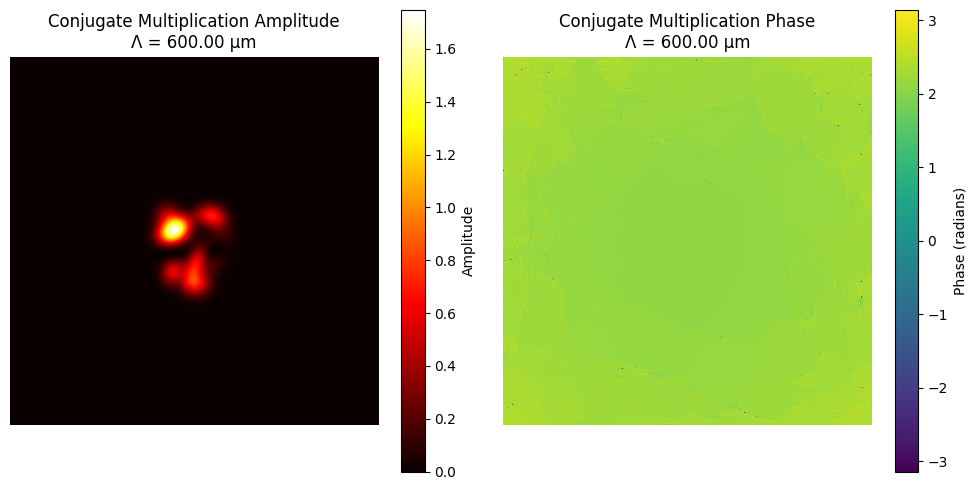

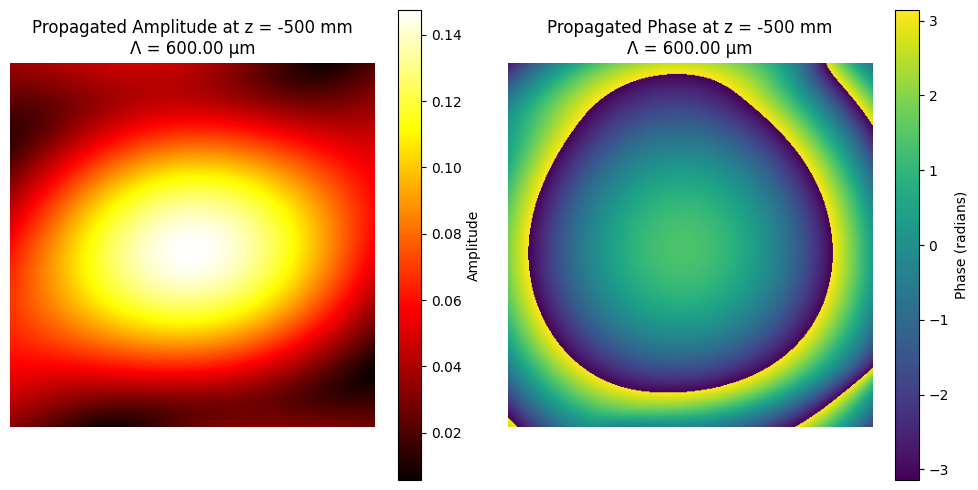

In [30]:
import numpy as np
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

def ASM(E_input, wavelength, dx, dy, propagation_distance, freqfilt=False):
    pad = 4000  # Increase padding for large synthetic wavelength
    E_input = np.pad(E_input, pad)
    [Ny, Nx] = E_input.shape
    E_input_fft = np.fft.fft2(E_input)
    wave_number = 2 * np.pi / wavelength  # Use 2π/λ for wave number
    kx = np.fft.fftshift(np.arange(-Nx/2, Nx/2) / (Nx * dx))
    ky = np.fft.fftshift(np.arange(-Ny/2, Ny/2) / (Ny * dy))
    [KX, KY] = np.meshgrid(kx, ky)
    
    # Compute the propagation kernel
    k_squared = wave_number**2
    kx_ky_squared = KX**2 + KY**2
    kz = np.sqrt(k_squared - kx_ky_squared + 0j)  # Add 0j to ensure complex output
    propagation_function = np.exp(1j * propagation_distance * kz)
    
    # Handle evanescent waves (set to zero where kx^2 + ky^2 > k^2)
    evanescent_mask = kx_ky_squared > k_squared
    propagation_function[evanescent_mask] = 0
    
    # Apply the propagation in the frequency domain
    E_input_fft_propagated = E_input_fft * propagation_function
    E_input_propagated = np.fft.ifft2(E_input_fft_propagated)
    
    # Remove padding
    E_input_propagated = E_input_propagated[pad:-pad, pad:-pad]
    
    return E_input_propagated

def main():
    # Parameters
    x_max = 0.01      # 10mm half-width in meters
    z_m = 0.5         # 500mm in meters
    n_pixels = 1000   # Using a smaller size for faster computation
    display_size = 400 # Size of the region to display
    
    # Parameters for the diffuser
    sigma = 10e-6     # 10 μm roughness standard deviation in meters
    sigma_filter = 11  # Sigma for Gaussian filter in pixels
    n_refractive_index = 1
    
    # Target synthetic wavelength (approximately 600 μm)
    synthetic_wavelength_target = 600e-6  # 600 μm
    
    # Choose two wavelengths that yield the target synthetic wavelength
    lambda_1 = 630e-9  # 630 nm
    lambda_2 = lambda_1 * synthetic_wavelength_target / (synthetic_wavelength_target - lambda_1)
    
    # Calculate the actual synthetic wavelength
    synthetic_wavelength = (lambda_1 * lambda_2) / abs(lambda_2 - lambda_1)
    
    print(f"λ1 = {lambda_1*1e9:.2f} nm")
    print(f"λ2 = {lambda_2*1e9:.2f} nm")
    print(f"Synthetic wavelength Λ = {synthetic_wavelength*1e6:.2f} μm")
    print(f"Wavelength difference Δλ = {(lambda_2-lambda_1)*1e9:.4f} nm")
    
    # Create a fixed diffuser (single realization)
    np.random.seed(42)  # For reproducibility
    zrough_raw = sigma * np.random.randn(n_pixels, n_pixels)
    zrough = gaussian_filter(zrough_raw, sigma=sigma_filter)
    
    # Create coordinate system at diffuser plane (z = 500mm)
    x = np.linspace(-x_max, x_max, n_pixels)
    y = np.linspace(-x_max, x_max, n_pixels)
    X, Y = np.meshgrid(x, y)
    Z = np.full((n_pixels, n_pixels), z_m)
    
    # Calculate distance from point source at (0,0,0) to each point on diffuser
    r = np.sqrt(X**2 + Y**2 + Z**2)
    
    # Calculate fields for λ1 and λ2
    wavelengths = [lambda_1, lambda_2]
    fields = []
    
    for lambda_m in wavelengths:
        # Phi rough (phase due to surface roughness)
        phi_rough = 2 * np.pi * zrough * n_refractive_index / lambda_m
        
        # Calculate wave number
        k = 2 * np.pi / lambda_m
        
        # Phase due to propagation
        theta_lambda = k * r
        
        # Create field at diffuser plane with roughness
        U_diffuser = (1 / r) * np.exp(1j * (theta_lambda + phi_rough))  # Add 1/r factor
        
        # Low-pass filtering of the complex field
        U_real_filtered = gaussian_filter(np.real(U_diffuser), sigma=sigma_filter)
        U_imag_filtered = gaussian_filter(np.imag(U_diffuser), sigma=sigma_filter)
        U_filtered = U_real_filtered + 1j * U_imag_filtered
        
        fields.append(U_filtered)
    
    # Calculate synthetic wavelength hologram
    U_synthetic = fields[0] * np.conjugate(fields[1])
    
    # Extract center region for display
    center = n_pixels // 2
    start_idx = center - display_size // 2
    end_idx = center + display_size // 2
    
    # Amplitude and phase of the conjugate multiplication field (U_synthetic)
    amplitude_synthetic = np.abs(U_synthetic)
    phase_synthetic = np.angle(U_synthetic)
    
    amplitude_synthetic_display = amplitude_synthetic[start_idx:end_idx, start_idx:end_idx]
    phase_synthetic_display = phase_synthetic[start_idx:end_idx, start_idx:end_idx]
    
    # Propagate the synthetic field at the synthetic wavelength
    dx = dy = 2 * x_max / n_pixels  # Pixel size in meters
    propagation_distance = -z_m  # Back-propagate to z = 0
    U_propagated = ASM(U_synthetic, synthetic_wavelength, dx, dy, propagation_distance)
    
    # Check the propagated field for issues
    if np.any(np.isnan(U_propagated)):
        print("Warning: NaNs detected in propagated field!")
    print(f"Propagated field min: {np.min(np.abs(U_propagated)):.2e}, max: {np.max(np.abs(U_propagated)):.2e}")
    
    # Amplitude and phase of the propagated field
    amplitude_propagated = np.abs(U_propagated)
    phase_propagated = np.angle(U_propagated)
    
    amplitude_propagated_display = amplitude_propagated[start_idx:end_idx, start_idx:end_idx]
    phase_propagated_display = phase_propagated[start_idx:end_idx, start_idx:end_idx]
    
    # Plot amplitude and phase of conjugate multiplication (U_synthetic)
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    
    # Amplitude of U_synthetic
    im1 = axs[0].imshow(amplitude_synthetic_display, cmap='hot')
    axs[0].set_title(f'Conjugate Multiplication Amplitude\nΛ = {synthetic_wavelength*1e6:.2f} μm')
    axs[0].axis('off')
    plt.colorbar(im1, ax=axs[0], label='Amplitude')
    
    # Phase of U_synthetic
    im2 = axs[1].imshow(phase_synthetic_display, cmap='viridis', 
                        norm=Normalize(vmin=-np.pi, vmax=np.pi))
    axs[1].set_title(f'Conjugate Multiplication Phase\nΛ = {synthetic_wavelength*1e6:.2f} μm')
    axs[1].axis('off')
    plt.colorbar(im2, ax=axs[1], label='Phase (radians)')
    
    plt.tight_layout()
    plt.savefig('conjugate_multiplication_amplitude_phase.png', dpi=300)
    
    # Plot amplitude and phase of propagated field
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    
    # Amplitude of propagated field
    im1 = axs[0].imshow(amplitude_propagated_display, cmap='hot')
    axs[0].set_title(f'Propagated Amplitude at z = {propagation_distance*1000:.0f} mm\nΛ = {synthetic_wavelength*1e6:.2f} μm')
    axs[0].axis('off')
    plt.colorbar(im1, ax=axs[0], label='Amplitude')
    
    # Phase of propagated field
    im2 = axs[1].imshow(phase_propagated_display, cmap='viridis', 
                        norm=Normalize(vmin=-np.pi, vmax=np.pi))
    axs[1].set_title(f'Propagated Phase at z = {propagation_distance*1000:.0f} mm\nΛ = {synthetic_wavelength*1e6:.2f} μm')
    axs[1].axis('off')
    plt.colorbar(im2, ax=axs[1], label='Phase (radians)')
    
    plt.tight_layout()
    plt.savefig('propagated_amplitude_phase.png', dpi=300)
    
    plt.show()

if __name__ == "__main__":
    main()

## Todo: need change the lambda 1 and 2 and see the diff